<a href="https://colab.research.google.com/github/Sanjana-Munikrishnappa/ML_Saftey_Retrained/blob/ML-Saftey-Retrained/ML_Excercise__7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setup: Mount Google Drive

Mounts your Google Drive to the Colab environment, allowing access to files stored in your Drive, such as the dataset used in this notebook.

In [ ]:
from google.colab import drive as gdrive

gdrive.mount("/content/drive")

Mounted at /content/drive


## Explore Dataset Contents

Defines the path to the `carla_dataset` on Google Drive and then lists the names of all files and folders within that directory. This helps in understanding the structure and contents of the dataset.

In [ ]:
from pathlib import Path

dataset_path = Path("/content/drive/MyDrive/carla_dataset")

print([item.name for item in dataset_path.iterdir()])

['test.zip', 'train.zip', 'validation.zip', 'train', 'test', 'validation', 'test-fog.zip', 'test-night.zip', 'test-town-01.zip', 'traffic_light_model.pth', 'pedestrian_model.pth', 'vehicle_model.pth']


## Unzip Dataset Files

Unzips several compressed dataset files (`.zip`) into specified directories within the `/content/` folder. This prepares the image data for use by extracting them from their archives.

In [ ]:
from pathlib import Path
from zipfile import ZipFile

dataset_dir = Path("/content/drive/MyDrive/carla_dataset")

zip_files = {
    "test.zip": "/content/test",
    "test-fog.zip": "/content/test-fog",
    "test-night.zip": "/content/test-night",
    "test-town-01.zip": "/content/test-town"
}

for zip_name, output_dir in zip_files.items():
    with ZipFile(dataset_dir / zip_name, "r") as archive:
        archive.extractall(output_dir)

## Verify Unzipped Folders

After unzipping, iterates through the newly created content folders (`/content/test`, `/content/test-fog`, etc.) and prints the names of their direct subdirectories. This confirms that the unzipping process was successful and the expected folder structure is present.

In [ ]:
from pathlib import Path

folders = {
    "TEST": "/content/test",
    "FOG": "/content/test-fog",
    "NIGHT": "/content/test-night",
    "TOWN": "/content/test-town"
}

for name, folder in folders.items():
    print(f"{name}:")
    print([item.name for item in Path(folder).iterdir()])
    print()

TEST:
['test']

FOG:
['test-fog']

NIGHT:
['test-night']

TOWN:
['test-town-01']



## Import Libraries

Imports all the necessary Python libraries for data manipulation, deep learning, and visualization. These include `numpy`, `pandas`, `torch`, `PIL (Pillow)`, `matplotlib`, `torch.nn`, `torch.utils.data`, and `torchvision.transforms`.

In [ ]:
import numpy as np
import pandas as pd
import torch
from PIL import Image

import matplotlib.pyplot as plt
from torch import nn
from torch.utils.data import Dataset
from torchvision import transforms

## Define Custom Dataset Class: `DrivingDataset224`

Defines a custom PyTorch `Dataset` class named `DrivingDataset224`. This class is responsible for loading images from a specified folder and their corresponding labels from a DataFrame. It also applies optional transformations to the images, making it suitable for use with PyTorch's `DataLoader`.

In [ ]:
from pathlib import Path

class DrivingDataset224(Dataset):

    def __init__(self, image_folder, labels_df, target_column, transform=None):
        self.image_folder = Path(image_folder)
        self.labels_df = labels_df.reset_index(drop=True)
        self.target_column = target_column
        self.transform = transform

    def __len__(self):
        return self.labels_df.shape[0]

    def __getitem__(self, index):
        row = self.labels_df.iloc[index]

        frame_name = f"{row['frame']}.png"
        image_file = self.image_folder / frame_name

        image = Image.open(image_file).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        label = row[self.target_column]

        return image, label

## Define Image Transformations

Defines a `torchvision.transforms.Compose` object named `transform_224`. This transformer will resize images to `(128, 128)` pixels and then convert them into PyTorch tensors. These transformations are crucial for preparing images for input into a neural network.

In [ ]:
transform_224 = transforms.Compose(
    [
        transforms.Resize(size=(128, 128)),
        transforms.ToTensor()
    ]
)

## Load Test Labels

Loads the `labels.csv` file from the `/content/test/test/` directory into a pandas DataFrame named `labels_df_test`. It then prints the shape of the DataFrame and displays the first 5 rows, providing an initial look at the ground truth labels for the test dataset.

In [ ]:
from pathlib import Path
import pandas as pd

test_labels_path = Path("/content/test/test/labels.csv")

labels_df_test = pd.read_csv(test_labels_path)

print(f"Shape: {labels_df_test.shape}")
display(labels_df_test.iloc[:5])

Shape: (3600, 7)


,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
0,0,False,False,False,15,0,35
1,10,True,False,True,299,0,116
2,20,True,False,True,298,0,307
3,30,True,False,True,297,0,258
4,40,True,False,True,297,0,249


## List Sunny Test Images

Defines the path to the sunny test images (`/content/test/test/rgb-front`) and then lists and sorts all image filenames within that folder. It prints the total number of images found and the first 5 filenames, confirming the availability of image data.

In [ ]:
from pathlib import Path

image_folder = Path("/content/test/test/rgb-front")

files = sorted(file.name for file in image_folder.iterdir())

print("Total images:", len(files))
print(files[:5])

Total images: 3600
['000000.jpg', '000010.jpg', '000020.jpg', '000030.jpg', '000040.jpg']


## Display Sample Sunny Images

Visualizes a selection of sunny images from the `image_folder`. It creates a subplot grid and displays five chosen images, each with a title indicating 'Sunny'. This provides a visual inspection of the sunny condition dataset.

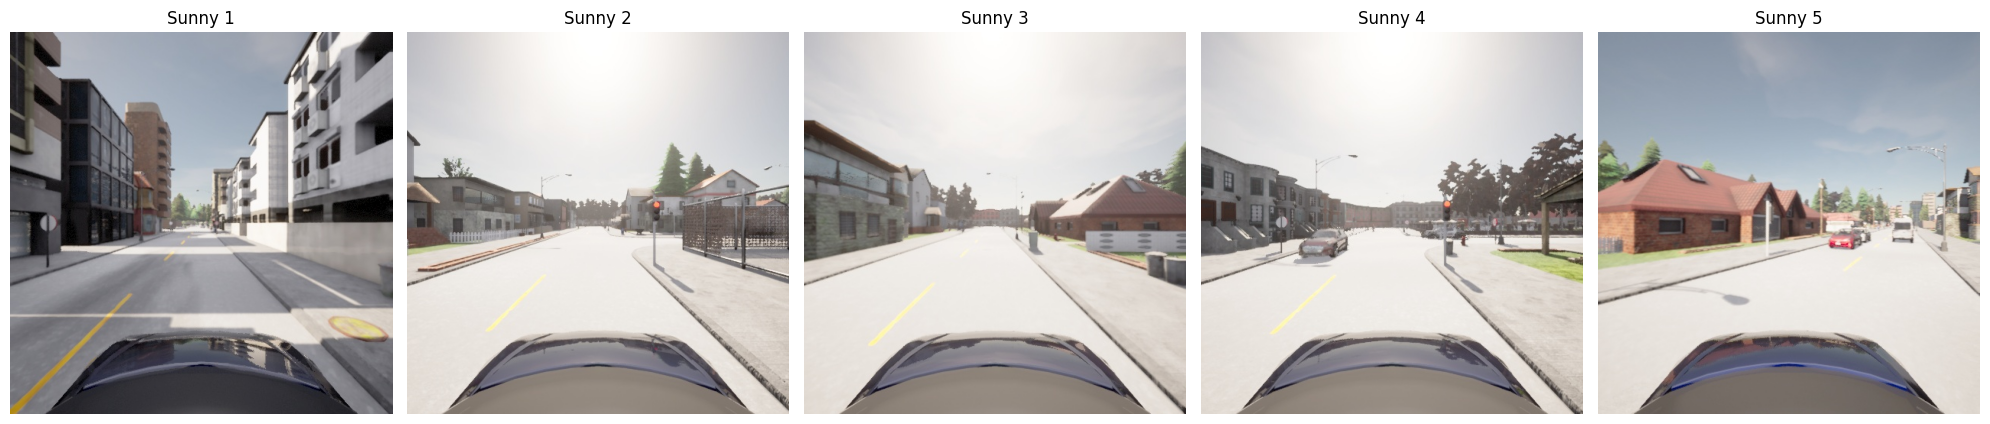

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

selected_indices = [0, 100, 500, 1000, 1500]

fig, axes = plt.subplots(1, len(selected_indices), figsize=(20, 8))

for position, image_index in enumerate(selected_indices):
    image_path = image_folder / files[image_index]
    image = Image.open(image_path)

    axes[position].imshow(image)
    axes[position].set_title(f"Sunny {position + 1}")
    axes[position].set_axis_off()

plt.tight_layout()
plt.show()

## List Fog Test Images

Sets the path to the fog test images (`/content/test-fog/test-fog/rgb-front`) and then lists and sorts all image filenames within that folder. It prints the total number of fog images and the first 5 filenames.

In [ ]:
from pathlib import Path

fog_folder = Path("/content/test-fog/test-fog/rgb-front")

fog_files = sorted(file.name for file in fog_folder.iterdir())

print("Fog images:", len(fog_files))
print(fog_files[:5])

Fog images: 3600
['000000.jpg', '000010.jpg', '000020.jpg', '000030.jpg', '000040.jpg']


## Display Sample Fog Images

Similar to the sunny images, displays five selected images from the `fog_folder`. Each image is titled 'Fog', allowing for a visual comparison of images under foggy conditions.

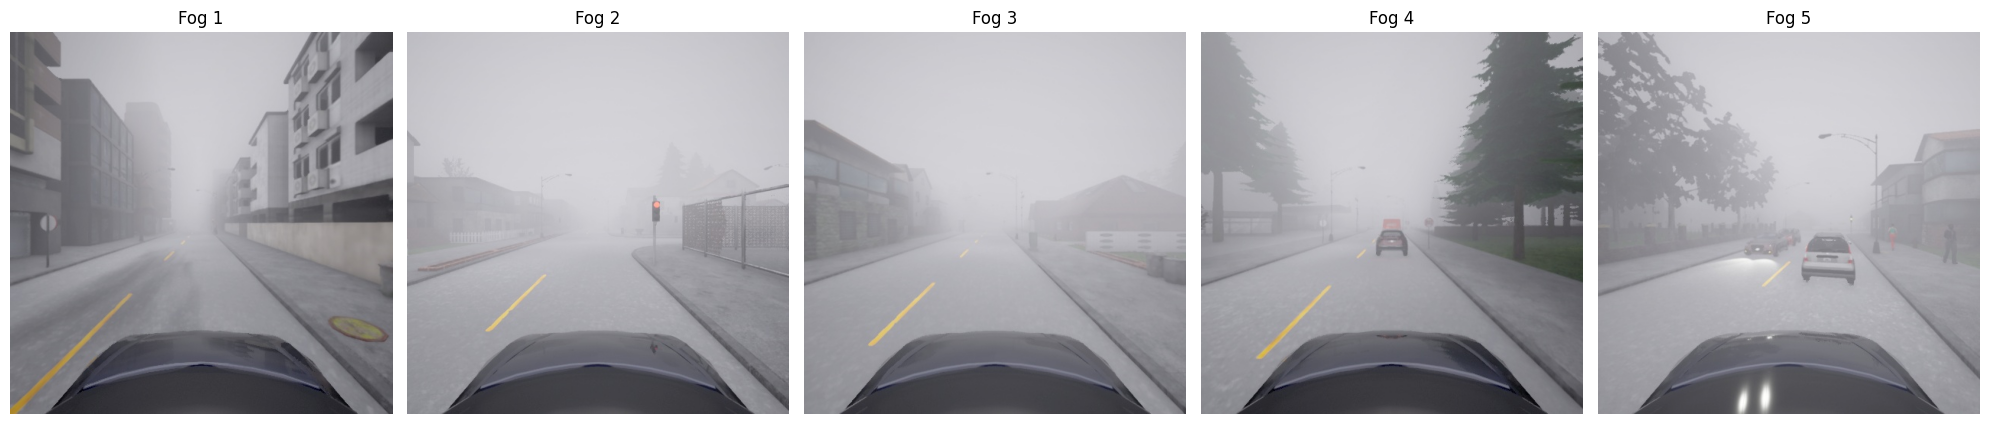

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

selected_indices = [0, 100, 500, 1000, 1500]

fig, axes = plt.subplots(
    1, len(selected_indices),
    figsize=(20, 8)
)

for position, image_index in enumerate(selected_indices):
    image_path = fog_folder / fog_files[image_index]
    image = Image.open(image_path)

    axes[position].imshow(image)
    axes[position].set_title(f"Fog {position + 1}")
    axes[position].set_axis_off()

plt.tight_layout()
plt.show()

## List Night Test Images

Specifies the path to the night test images (`/content/test-night/test-night/rgb-front`) and then lists and sorts all image filenames within it. It outputs the total count of night images and the first five names.

In [ ]:
from pathlib import Path

night_folder = Path("/content/test-night/test-night/rgb-front")

night_files = sorted(item.name for item in night_folder.iterdir())

print("Night images:", len(night_files))
print(night_files[:5])

Night images: 3600
['000000.jpg', '000010.jpg', '000020.jpg', '000030.jpg', '000040.jpg']


## Display Sample Night Images

Visualizes five sample images from the `night_folder`, labeling each as 'Night'. This helps in understanding the visual characteristics of the dataset collected during nighttime.

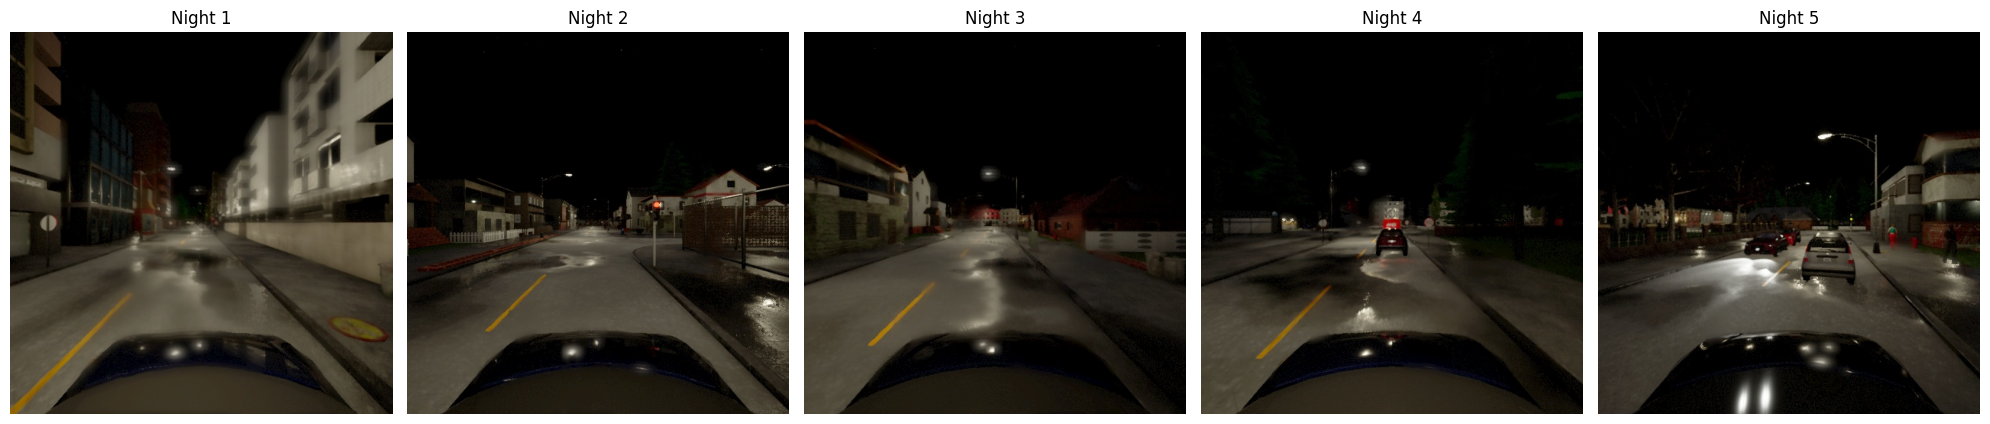

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

selected_indices = [0, 100, 500, 1000, 1500]

fig, axes = plt.subplots(
    1, len(selected_indices),
    figsize=(20, 8)
)

for position, image_index in enumerate(selected_indices):
    image_path = night_folder / night_files[image_index]
    image = Image.open(image_path)

    axes[position].imshow(image)
    axes[position].set_title(f"Night {position + 1}")
    axes[position].set_axis_off()

plt.tight_layout()
plt.show()

## List Different Town Test Images

Points to the images collected from a different town (`/content/test-town/test-town-01/rgb-front`) and lists their filenames. It shows the total count and the first five filenames, indicating data from a potentially different environment.

In [ ]:
from pathlib import Path

town_folder = Path("/content/test-town/test-town-01/rgb-front")

town_files = sorted(item.name for item in town_folder.iterdir())

print("Town images:", len(town_files))
print(town_files[:5])

Town images: 3600
['000000.jpg', '000010.jpg', '000020.jpg', '000030.jpg', '000040.jpg']


## Display Sample Different Town Images

Showcases five selected images from the `town_folder`, titling each 'Town'. This allows for a visual examination of images from an environment that is out-of-distribution (OOD) compared to the 'sunny' condition.

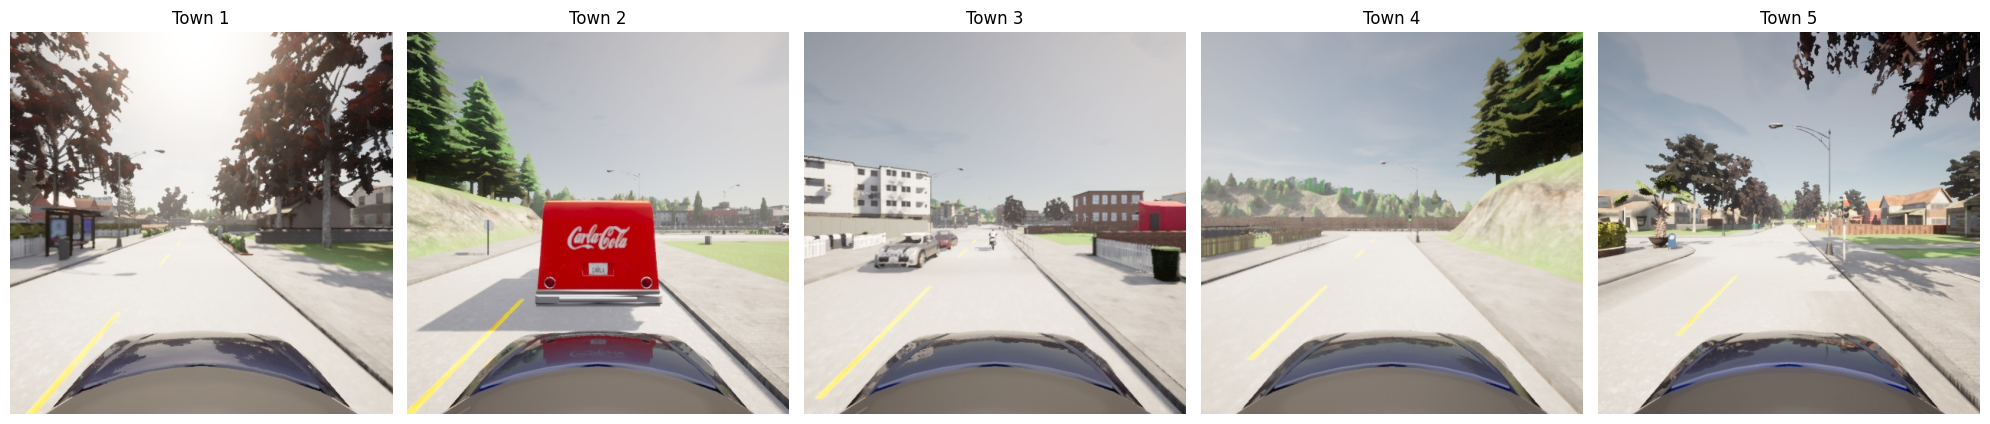

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

selected_indices = [0, 100, 500, 1000, 1500]

fig, axes = plt.subplots(1, len(selected_indices), figsize=(20, 8))

for position, image_index in enumerate(selected_indices):
    image_path = town_folder / town_files[image_index]
    image = Image.open(image_path)

    axes[position].imshow(image)
    axes[position].set_title(f"Town {position + 1}")
    axes[position].set_axis_off()

plt.tight_layout()
plt.show()

## Load Traffic Light Model Checkpoint

Loads the `traffic_light_model.pth` file, which contains the pretrained weights for a traffic light detection model, using `torch.load`. It then prints the keys available in the loaded checkpoint, giving insight into the saved components of the model (e.g., layers, optimizer state).

In [ ]:
from pathlib import Path
import torch

model_file = Path(
    "/content/drive/MyDrive/carla_dataset/traffic_light_model.pth"
)

checkpoint = torch.load(model_file, map_location=torch.device("cpu"))

print(checkpoint.keys())

odict_keys(['model.0.weight', 'model.0.bias', 'model.3.weight', 'model.3.bias', 'model.6.weight', 'model.6.bias', 'model.10.weight', 'model.10.bias', 'model.12.weight', 'model.12.bias'])


## Inspect Traffic Light Model State Dictionary

Loads the full state dictionary of the `traffic_light_model.pth` file and iterates through its items. For each named tensor (e.g., weights, biases), it prints the name and its shape. This is useful for verifying the architecture's compatibility with the loaded weights.

In [ ]:
import torch
from pathlib import Path

model_path = Path(
    "/content/drive/MyDrive/carla_dataset/traffic_light_model.pth"
)

state_dict = torch.load(
    model_path,
    map_location=torch.device("cpu")
)

for name, tensor in state_dict.items():
    print(f"{name} {tuple(tensor.shape)}")

model.0.weight (16, 3, 3, 3)
model.0.bias (16,)
model.3.weight (32, 16, 3, 3)
model.3.bias (32,)
model.6.weight (64, 32, 3, 3)
model.6.bias (64,)
model.10.weight (128, 50176)
model.10.bias (128,)
model.12.weight (1, 128)
model.12.bias (1,)


## Define and Load Traffic Light Model Architecture

Defines the sequential architecture of the `traffic_light_model` using `torch.nn.Sequential`, consisting of convolutional layers, ReLU activations, max-pooling, flattening, and linear layers. It then loads the pretrained weights from `traffic_light_model.pth` and applies them to the defined model, preparing it for inference. The `model.` prefix is removed from the keys to match the `nn.Sequential` structure.

In [ ]:
import torch
from torch import nn

traffic_light_model = nn.Sequential(
    nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),

    nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),

    nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
    nn.ReLU(),

    nn.Flatten(),
    nn.Identity(),

    nn.Linear(in_features=50176, out_features=128),
    nn.ReLU(),

    nn.Linear(in_features=128, out_features=1)
)

model_path = "/content/drive/MyDrive/carla_dataset/traffic_light_model.pth"

loaded_weights = torch.load(
    model_path,
    map_location=torch.device("cpu")
)

clean_weights = {
    key.removeprefix("model."): value
    for key, value in loaded_weights.items()
}

traffic_light_model.load_state_dict(clean_weights)
traffic_light_model.eval()

print("SUCCESS")

SUCCESS


## Print Traffic Light Model Architecture

Prints the detailed structure of the `traffic_light_model` using `print(str(traffic_light_model))`. This provides a clear overview of all the layers, their types, and their parameters (e.g., kernel size, stride, input/output channels/features).

In [ ]:
print(str(traffic_light_model))

Sequential(
  (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (7): ReLU()
  (8): Flatten(start_dim=1, end_dim=-1)
  (9): Identity()
  (10): Linear(in_features=50176, out_features=128, bias=True)
  (11): ReLU()
  (12): Linear(in_features=128, out_features=1, bias=True)
)


## Trace Image Through Traffic Light Model Layers

Takes a single sunny image, applies the `transform_224`, and then traces its input tensor through the `traffic_light_model` layer by layer. It prints the shape of the tensor after specific layers (Conv1, Pool1, Pool2, Conv3) and the flattened size, helping to understand how data dimensions change through the network.

In [ ]:
from PIL import Image
import torch

img_path = image_folder / files[0]
img = Image.open(img_path).convert("RGB")

x = transform_224(img).unsqueeze(0)

print("Input shape:", x.shape)

with torch.no_grad():
    layer_names = {
        0: "After Conv1",
        2: "After Pool1",
        5: "After Pool2",
        6: "After Conv3"
    }

    for layer_index, layer in enumerate(traffic_light_model):
        x = layer(x)

        if layer_index in layer_names:
            print(f"{layer_names[layer_index]}:", x.shape)

        if layer_index == 6:
            print("Flatten size:", x.numel())
            break

Input shape: torch.Size([1, 3, 128, 128])
After Conv1: torch.Size([1, 16, 126, 126])
After Pool1: torch.Size([1, 16, 63, 63])
After Pool2: torch.Size([1, 32, 30, 30])
After Conv3: torch.Size([1, 64, 28, 28])
Flatten size: 50176


## Make a Single Prediction with Traffic Light Model

Loads the first sunny image, transforms it, and feeds it into the `traffic_light_model` to get a raw prediction. The model is set to evaluation mode (`.eval()`) and inference is performed without gradient computation (`torch.inference_mode()`). The raw output tensor is then printed.

In [ ]:
img_path = image_folder / files[0]
image = Image.open(img_path).convert("RGB")

input_tensor = transform_224(image).unsqueeze(0)

traffic_light_model.eval()

with torch.inference_mode():
    prediction = traffic_light_model(input_tensor)

print(prediction)

tensor([[-1.4970]])


## Calculate Traffic Light Model Probability

Building on the previous step, takes the raw output from the `traffic_light_model` and applies a sigmoid function to convert it into a probability score between 0 and 1. Both the raw output and the calculated probability are printed, indicating the model's confidence in the presence of a traffic light.

In [ ]:
import torch

image_path = image_folder / files[0]
image = Image.open(image_path).convert("RGB")

input_data = transform_224(image).unsqueeze(0)

traffic_light_model.eval()

with torch.inference_mode():
    raw_prediction = traffic_light_model(input_data)

probability = torch.sigmoid(raw_prediction).item()
raw_value = raw_prediction.item()

print("Raw output:", raw_value)
print("Probability:", probability)

Raw output: -1.4970436096191406
Probability: 0.1828668713569641


## Visualize Traffic Light Model Predictions

Visualizes the first five sunny images along with their predicted traffic light probabilities. It loads each image, performs inference with the `traffic_light_model`, calculates the sigmoid probability, and displays the image with the probability as its title. This provides a qualitative assessment of the model's performance on in-distribution data.

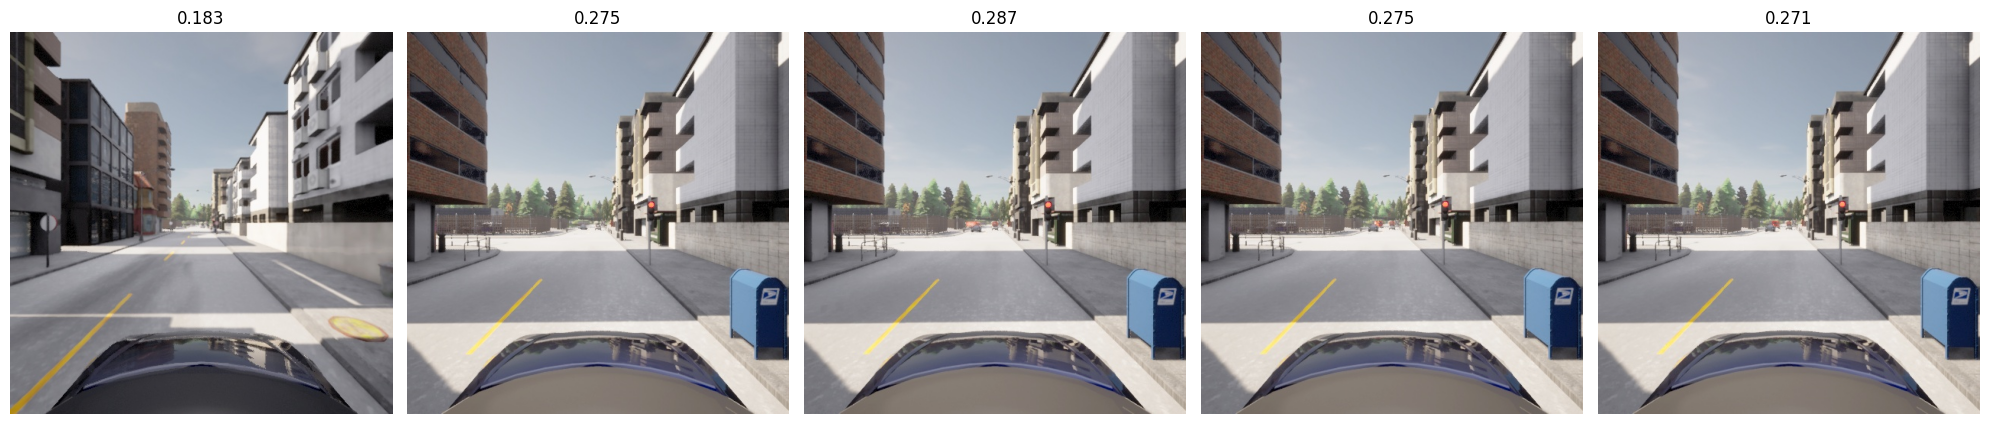

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(20, 8))

traffic_light_model.eval()

for index, filename in enumerate(files[:5]):
    image_path = image_folder / filename
    image = Image.open(image_path).convert("RGB")

    input_tensor = transform_224(image).unsqueeze(0)

    with torch.inference_mode():
        prediction = traffic_light_model(input_tensor)

    probability = torch.sigmoid(prediction).item()

    axes[index].imshow(image)
    axes[index].set_title(f"{probability:.3f}")
    axes[index].set_axis_off()

plt.tight_layout()
plt.show()

## Define `get_scores` Function

Defines a helper function `get_scores` that takes an image folder, a list of filenames, and a model as input. It iterates through a specified limit of images, processes each through the model, applies a sigmoid to the output, and returns a list of these probability scores. This function is designed to efficiently gather predictions for multiple images.

In [ ]:
import torch
import numpy as np
from PIL import Image

def get_scores(folder, file_list, model):
    results = []

    model.eval()

    for filename in file_list[:500]:
        image_path = folder / filename
        image = Image.open(image_path).convert("RGB")

        input_tensor = transform_224(image).unsqueeze(0)

        with torch.inference_mode():
            output = model(input_tensor)

        results.append(torch.sigmoid(output).item())

    return results

## Calculate Scores for Different Datasets

Uses the `get_scores` function to calculate the traffic light model's prediction probabilities for images from four different conditions: 'Sunny' (in-distribution), 'Fog', 'Night', and 'Town' (out-of-distribution). The results are stored in `score_sets` and then assigned to individual variables for further analysis. The number of scores collected for each dataset is also printed.

In [ ]:
datasets = {
    "Sunny": (image_folder, files),
    "Fog": (fog_folder, fog_files),
    "Night": (night_folder, night_files),
    "Town": (town_folder, town_files)
}

score_sets = {
    name: get_scores(folder, filenames, traffic_light_model)
    for name, (folder, filenames) in datasets.items()
}

sunny_scores = score_sets["Sunny"]
fog_scores = score_sets["Fog"]
night_scores = score_sets["Night"]
town_scores = score_sets["Town"]

for name, scores in score_sets.items():
    print(f"{name}:", len(scores))

Sunny: 500
Fog: 500
Night: 500
Town: 500


## Visualize Score Distributions

Generates histograms to visualize the distribution of prediction scores for the 'Sunny', 'Fog', 'Night', and 'Different Town' datasets. These histograms help in understanding how the model's confidence scores are distributed under different environmental conditions, particularly for identifying out-of-distribution (OOD) data.

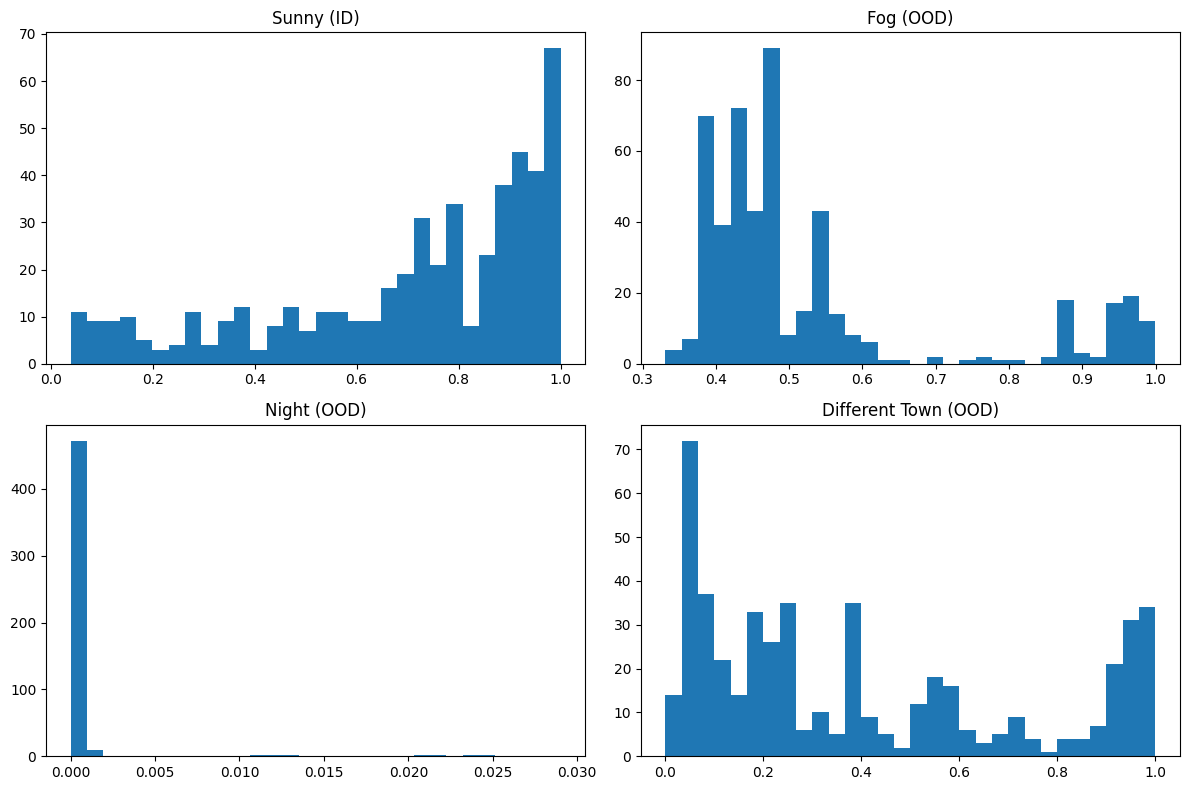

In [ ]:
import matplotlib.pyplot as plt

score_groups = [
    ("Sunny (ID)", sunny_scores),
    ("Fog (OOD)", fog_scores),
    ("Night (OOD)", night_scores),
    ("Different Town (OOD)", town_scores)
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for axis, (title, scores) in zip(axes.ravel(), score_groups):
    axis.hist(scores, bins=30)
    axis.set_title(title)

fig.tight_layout()
plt.show()

## Calculate MSP AUROC for OOD Detection

Prepares data to calculate the Area Under the Receiver Operating Characteristic curve (AUROC) using Maximum Softmax Probability (MSP) as an Out-of-Distribution (OOD) detection metric. It combines scores from the in-distribution ('Sunny') and out-of-distribution ('Fog', 'Night', 'Town') datasets, assigns ground truth labels (0 for ID, 1 for OOD), and computes the MSP AUROC, which quantifies the model's ability to distinguish between ID and OOD samples.

In [ ]:
from sklearn.metrics import roc_auc_score
import numpy as np

in_distribution = np.asarray(sunny_scores)

out_distribution = np.hstack(
    (fog_scores, night_scores, town_scores)
)

ground_truth = np.r_[
    np.zeros(in_distribution.size),
    np.ones(out_distribution.size)
]

confidence_scores = np.r_[
    in_distribution,
    out_distribution
]

msp_auroc = roc_auc_score(
    y_true=ground_truth,
    y_score=-confidence_scores
)

print(f"MSP AUROC = {msp_auroc:.6f}")

MSP AUROC = 0.816017


## Extract Features for kNN

Defines an `extract_features` function that takes an image folder, a list of filenames, and a model. It processes a limited number of images through the convolutional layers of the model (`model[:9]`) to obtain feature maps. These feature maps are then flattened into feature vectors and stored as NumPy arrays. This is a crucial step for implementing k-Nearest Neighbors (kNN) based Out-of-Distribution (OOD) detection, as kNN relies on distance in a feature space.

In [ ]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import torch
from PIL import Image

def extract_features(folder, file_list, model):
    features = []

    model.eval()

    for filename in file_list[:300]:
        image_path = folder / filename
        image = Image.open(image_path).convert("RGB")

        input_tensor = transform_224(image).unsqueeze(0)

        with torch.inference_mode():
            feature_map = model[:9](input_tensor)

        feature_vector = feature_map.flatten().cpu().numpy()
        features.append(feature_vector)

    return np.asarray(features)


feature_sets = {
    "train": (image_folder, files),
    "fog": (fog_folder, fog_files),
    "night": (night_folder, night_files),
    "town": (town_folder, town_files)
}

extracted = {
    name: extract_features(folder, filenames, traffic_light_model)
    for name, (folder, filenames) in feature_sets.items()
}

train_feats = extracted["train"]
fog_feats = extracted["fog"]
night_feats = extracted["night"]
town_feats = extracted["town"]

print(train_feats.shape)

(300, 50176)


## Calculate kNN AUROC for OOD Detection

Calculates the k-Nearest Neighbors (kNN) AUROC for Out-of-Distribution (OOD) detection. It first builds a `NearestNeighbors` model using features extracted from the in-distribution (sunny) dataset. Then, it calculates the distances of both in-distribution and OOD features to their nearest neighbors in the trained kNN model. Finally, it computes the AUROC score based on these distances, evaluating kNN's effectiveness in identifying OOD samples.

In [ ]:
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import roc_auc_score
import numpy as np

# Build the nearest-neighbour model using ID features
knn = NearestNeighbors(n_neighbors=1)
knn.fit(train_feats)

feature_sets = {
    "id": train_feats,
    "fog": fog_feats,
    "night": night_feats,
    "town": town_feats
}

distances = {}

for name, features in feature_sets.items():
    distance, _ = knn.kneighbors(features)
    distances[name] = distance.ravel()

id_scores_knn = distances["id"]

ood_scores_knn = np.concatenate([
    distances["fog"],
    distances["night"],
    distances["town"]
])

labels = np.concatenate([
    np.zeros(id_scores_knn.size),
    np.ones(ood_scores_knn.size)
])

scores = np.concatenate([
    id_scores_knn,
    ood_scores_knn
])

auroc_knn = roc_auc_score(
    y_true=labels,
    y_score=scores
)

print("kNN AUROC =", auroc_knn)

kNN AUROC = 1.0


## Define `create_carla_model` Function

Defines a reusable function `create_carla_model()` that returns a `torch.nn.Sequential` model with the same convolutional and linear layer architecture as the `traffic_light_model`. This function simplifies the creation of similar models for other detection tasks, such as pedestrian and vehicle detection, by ensuring consistent architecture.

In [ ]:
import torch
from torch import nn

def create_carla_model():
    return nn.Sequential(
        nn.Conv2d(3, 16, 3),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(16, 32, 3),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(32, 64, 3),
        nn.ReLU(),

        nn.Flatten(),
        nn.Identity(),

        nn.Linear(50176, 128),
        nn.ReLU(),

        nn.Linear(128, 1)
    )

## Load Pedestrian Model

Creates a new model instance using `create_carla_model()`, then loads the pretrained weights for a pedestrian detection model from `pedestrian_model.pth`. It processes the loaded weights to match the model's structure and sets the model to evaluation mode. A confirmation message is printed upon successful loading.

In [ ]:
pedestrian_model = create_carla_model()

pedestrian_path = "/content/drive/MyDrive/carla_dataset/pedestrian_model.pth"

pedestrian_weights = torch.load(
    pedestrian_path,
    map_location=torch.device("cpu")
)

pedestrian_weights = {
    key.removeprefix("model."): value
    for key, value in pedestrian_weights.items()
}

pedestrian_model.load_state_dict(pedestrian_weights)
pedestrian_model.eval()

print("Pedestrian model loaded successfully")

Pedestrian model loaded successfully


## Load Vehicle Model

Similar to the pedestrian model, initializes another model using `create_carla_model()`, loads the pretrained weights for a vehicle detection model from `vehicle_model.pth`, adapts the weights to the model's structure, and sets it to evaluation mode. A success message is printed to confirm the model is ready.

In [ ]:
vehicle_model = create_carla_model()

vehicle_path = "/content/drive/MyDrive/carla_dataset/vehicle_model.pth"

vehicle_weights = torch.load(
    vehicle_path,
    map_location=torch.device("cpu")
)

vehicle_weights = {
    key.removeprefix("model."): value
    for key, value in vehicle_weights.items()
}

vehicle_model.load_state_dict(vehicle_weights)
vehicle_model.eval()

print("Vehicle model loaded successfully")

Vehicle model loaded successfully


## Define `mean_confidence` Function

Defines a helper function `mean_confidence` that calculates the average sigmoid probability (confidence) for a given model across a list of images in a specified folder. It processes a limited number of images, performs inference, converts raw outputs to probabilities using sigmoid, and then returns the mean of these probabilities. This function is useful for quantitatively assessing model confidence under various conditions.

In [ ]:
import numpy as np
import torch
from PIL import Image

def mean_confidence(folder, file_list, model, limit=500):
    probabilities = []

    for filename in file_list[:limit]:
        image = Image.open(folder / filename).convert("RGB")
        input_tensor = transform_224(image).unsqueeze(0)

        with torch.inference_mode():
            output = model(input_tensor)

        probability = torch.sigmoid(output).item()
        probabilities.append(probability)

    return np.mean(probabilities)

## Calculate Traffic Light Confidence Across Conditions

Uses the `mean_confidence` function to calculate the average prediction confidence of the `traffic_light_model` for images from the 'Sunny', 'Fog', and 'Night' conditions. The results are stored in a dictionary and then printed, showing how the model's average confidence varies with different environmental factors.

In [ ]:
traffic_confidence = {
    "Sunny": mean_confidence(image_folder, files, traffic_light_model),
    "Fog": mean_confidence(fog_folder, fog_files, traffic_light_model),
    "Night": mean_confidence(night_folder, night_files, traffic_light_model)
}

print("Traffic Light Model")
print("Sunny:", traffic_confidence["Sunny"])
print("Fog:", traffic_confidence["Fog"])
print("Night:", traffic_confidence["Night"])

Traffic Light Model
Sunny: 0.7035145446360112
Fog: 0.5327819087505341
Night: 0.0007582776531835407


## Calculate Pedestrian Confidence Across Conditions

Calculates the average prediction confidence of the `pedestrian_model` for images under 'Sunny', 'Fog', and 'Night' conditions using the `mean_confidence` function. The computed mean confidences are printed, allowing for an assessment of the pedestrian model's robustness to different conditions.

In [ ]:
pedestrian_confidence = {
    "Sunny": mean_confidence(image_folder, files, pedestrian_model),
    "Fog": mean_confidence(fog_folder, fog_files, pedestrian_model),
    "Night": mean_confidence(night_folder, night_files, pedestrian_model)
}

print("Pedestrian Model")
print("Sunny:", pedestrian_confidence["Sunny"])
print("Fog:", pedestrian_confidence["Fog"])
print("Night:", pedestrian_confidence["Night"])

Pedestrian Model
Sunny: 0.35983172923885287
Fog: 0.3330102245807648
Night: 0.001917511580977589


## Calculate Vehicle Confidence Across Conditions

Calculates the average prediction confidence of the `vehicle_model` for images under 'Sunny', 'Fog', and 'Night' conditions using the `mean_confidence` function. The printed results provide insight into how the vehicle model's confidence levels are affected by varying environmental factors.

In [ ]:
vehicle_confidence = {
    "Sunny": mean_confidence(image_folder, files, vehicle_model),
    "Fog": mean_confidence(fog_folder, fog_files, vehicle_model),
    "Night": mean_confidence(night_folder, night_files, vehicle_model)
}

print("Vehicle Model")
print("Sunny:", vehicle_confidence["Sunny"])
print("Fog:", vehicle_confidence["Fog"])
print("Night:", vehicle_confidence["Night"])

Vehicle Model
Sunny: 0.8747370197176934
Fog: 0.7830125646591186
Night: 0.5069162071347236


## Summarize Mean Softmax Confidence

Consolidates and prints a summary of the mean softmax confidence scores for all three models (Traffic Light, Pedestrian, and Vehicle) across the 'Sunny', 'Fog', and 'Night' conditions. This table provides a clear overview of each model's average confidence in different environments.

In [ ]:
print("\nMean Softmax Confidence")
print("-" * 45)

for model_name, values in {
    "Traffic Light": traffic_confidence,
    "Pedestrian": pedestrian_confidence,
    "Vehicle": vehicle_confidence
}.items():

    print(f"\n{model_name}")
    for condition, value in values.items():
        print(f"{condition}: {value:.4f}")


Mean Softmax Confidence
---------------------------------------------

Traffic Light
Sunny: 0.7035
Fog: 0.5328
Night: 0.0008

Pedestrian
Sunny: 0.3598
Fog: 0.3330
Night: 0.0019

Vehicle
Sunny: 0.8747
Fog: 0.7830
Night: 0.5069


## Define `calculate_auroc` and Calculate MSP AUROC for OOD Scenarios

Defines a `calculate_auroc` helper function to compute the AUROC score given in-distribution (ID) and out-of-distribution (OOD) scores and their corresponding ground truth labels. It then uses this function to calculate the MSP (Maximum Softmax Probability) AUROC for three specific OOD scenarios: 'Fog', 'Night', and 'Different Town', using the previously computed `sunny_scores`, `fog_scores`, `night_scores`, and `town_scores`. These scores indicate the model's ability to detect OOD samples based on prediction confidence.

In [ ]:
from sklearn.metrics import roc_auc_score
import numpy as np

def calculate_auroc(id_scores, ood_scores):
    y_true = np.concatenate([
        np.zeros(len(id_scores)),
        np.ones(len(ood_scores))
    ])

    y_score = np.concatenate([
        -np.asarray(id_scores),
        -np.asarray(ood_scores)
    ])

    return roc_auc_score(y_true, y_score)


msp_fog = calculate_auroc(sunny_scores, fog_scores)
msp_night = calculate_auroc(sunny_scores, night_scores)
msp_town = calculate_auroc(sunny_scores, town_scores)

print("MSP AUROC")
print("Fog:", msp_fog)
print("Night:", msp_night)
print("Different Town:", msp_town)

MSP AUROC
Fog: 0.7064440000000001
Night: 1.0
Different Town: 0.741608


## Define `knn_auroc` and Calculate kNN AUROC for OOD Scenarios

Defines a `knn_auroc` helper function, similar to `calculate_auroc`, but specifically tailored for kNN distances. It then computes the kNN AUROC for the 'Fog', 'Night', and 'Different Town' OOD scenarios using the `id_scores_knn` and the kNN distances for each OOD dataset. This evaluates the effectiveness of kNN-based OOD detection.

In [ ]:
def knn_auroc(id_distances, ood_distances):
    y_true = np.concatenate([
        np.zeros(len(id_distances)),
        np.ones(len(ood_distances))
    ])

    scores = np.concatenate([
        id_distances,
        ood_distances
    ])

    return roc_auc_score(y_true, scores)


knn_fog = knn_auroc(
    id_scores_knn,
    distances["fog"]
)

knn_night = knn_auroc(
    id_scores_knn,
    distances["night"]
)

knn_town = knn_auroc(
    id_scores_knn,
    distances["town"]
)

print("k-NN AUROC")
print("Fog:", knn_fog)
print("Night:", knn_night)
print("Different Town:", knn_town)

k-NN AUROC
Fog: 1.0
Night: 1.0
Different Town: 1.0


## Compare OOD Detection Methods (MSP vs. kNN)

Compares the performance of MSP (Maximum Softmax Probability) and kNN (k-Nearest Neighbors) as Out-of-Distribution (OOD) detection methods across 'Fog', 'Night', and 'Different Town' scenarios. It displays the AUROC scores for both methods and calculates the 'gap' (absolute difference) between them for each scenario, highlighting which method performs better or has a larger discrepancy.

In [ ]:
results = {
    "Fog": (msp_fog, knn_fog),
    "Night": (msp_night, knn_night),
    "Different Town": (msp_town, knn_town)
}

print("OOD Detection Comparison")
print("-" * 60)

gaps = {}

for scenario, (msp, knn) in results.items():
    gap = abs(knn - msp)
    gaps[scenario] = gap

    print(
        f"{scenario:<18} "
        f"MSP: {msp:.4f}   "
        f"k-NN: {knn:.4f}   "
        f"Gap: {gap:.4f}"
    )

largest_gap = max(gaps, key=gaps.get)

print("\nLargest gap:", largest_gap)
print("Gap:", gaps[largest_gap])

OOD Detection Comparison
------------------------------------------------------------
Fog                MSP: 0.7064   k-NN: 1.0000   Gap: 0.2936
Night              MSP: 1.0000   k-NN: 1.0000   Gap: 0.0000
Different Town     MSP: 0.7416   k-NN: 1.0000   Gap: 0.2584

Largest gap: Fog
Gap: 0.29355599999999993


## Visualize Dataset Conditions

Generates a 4x5 grid of images, showcasing selected samples from each of the four dataset conditions: 'Sunny', 'Fog', 'Night', and 'Town'. This visualization provides a comprehensive overview of the visual characteristics and differences across the in-distribution and various out-of-distribution environments, which is essential for understanding the OOD detection task.

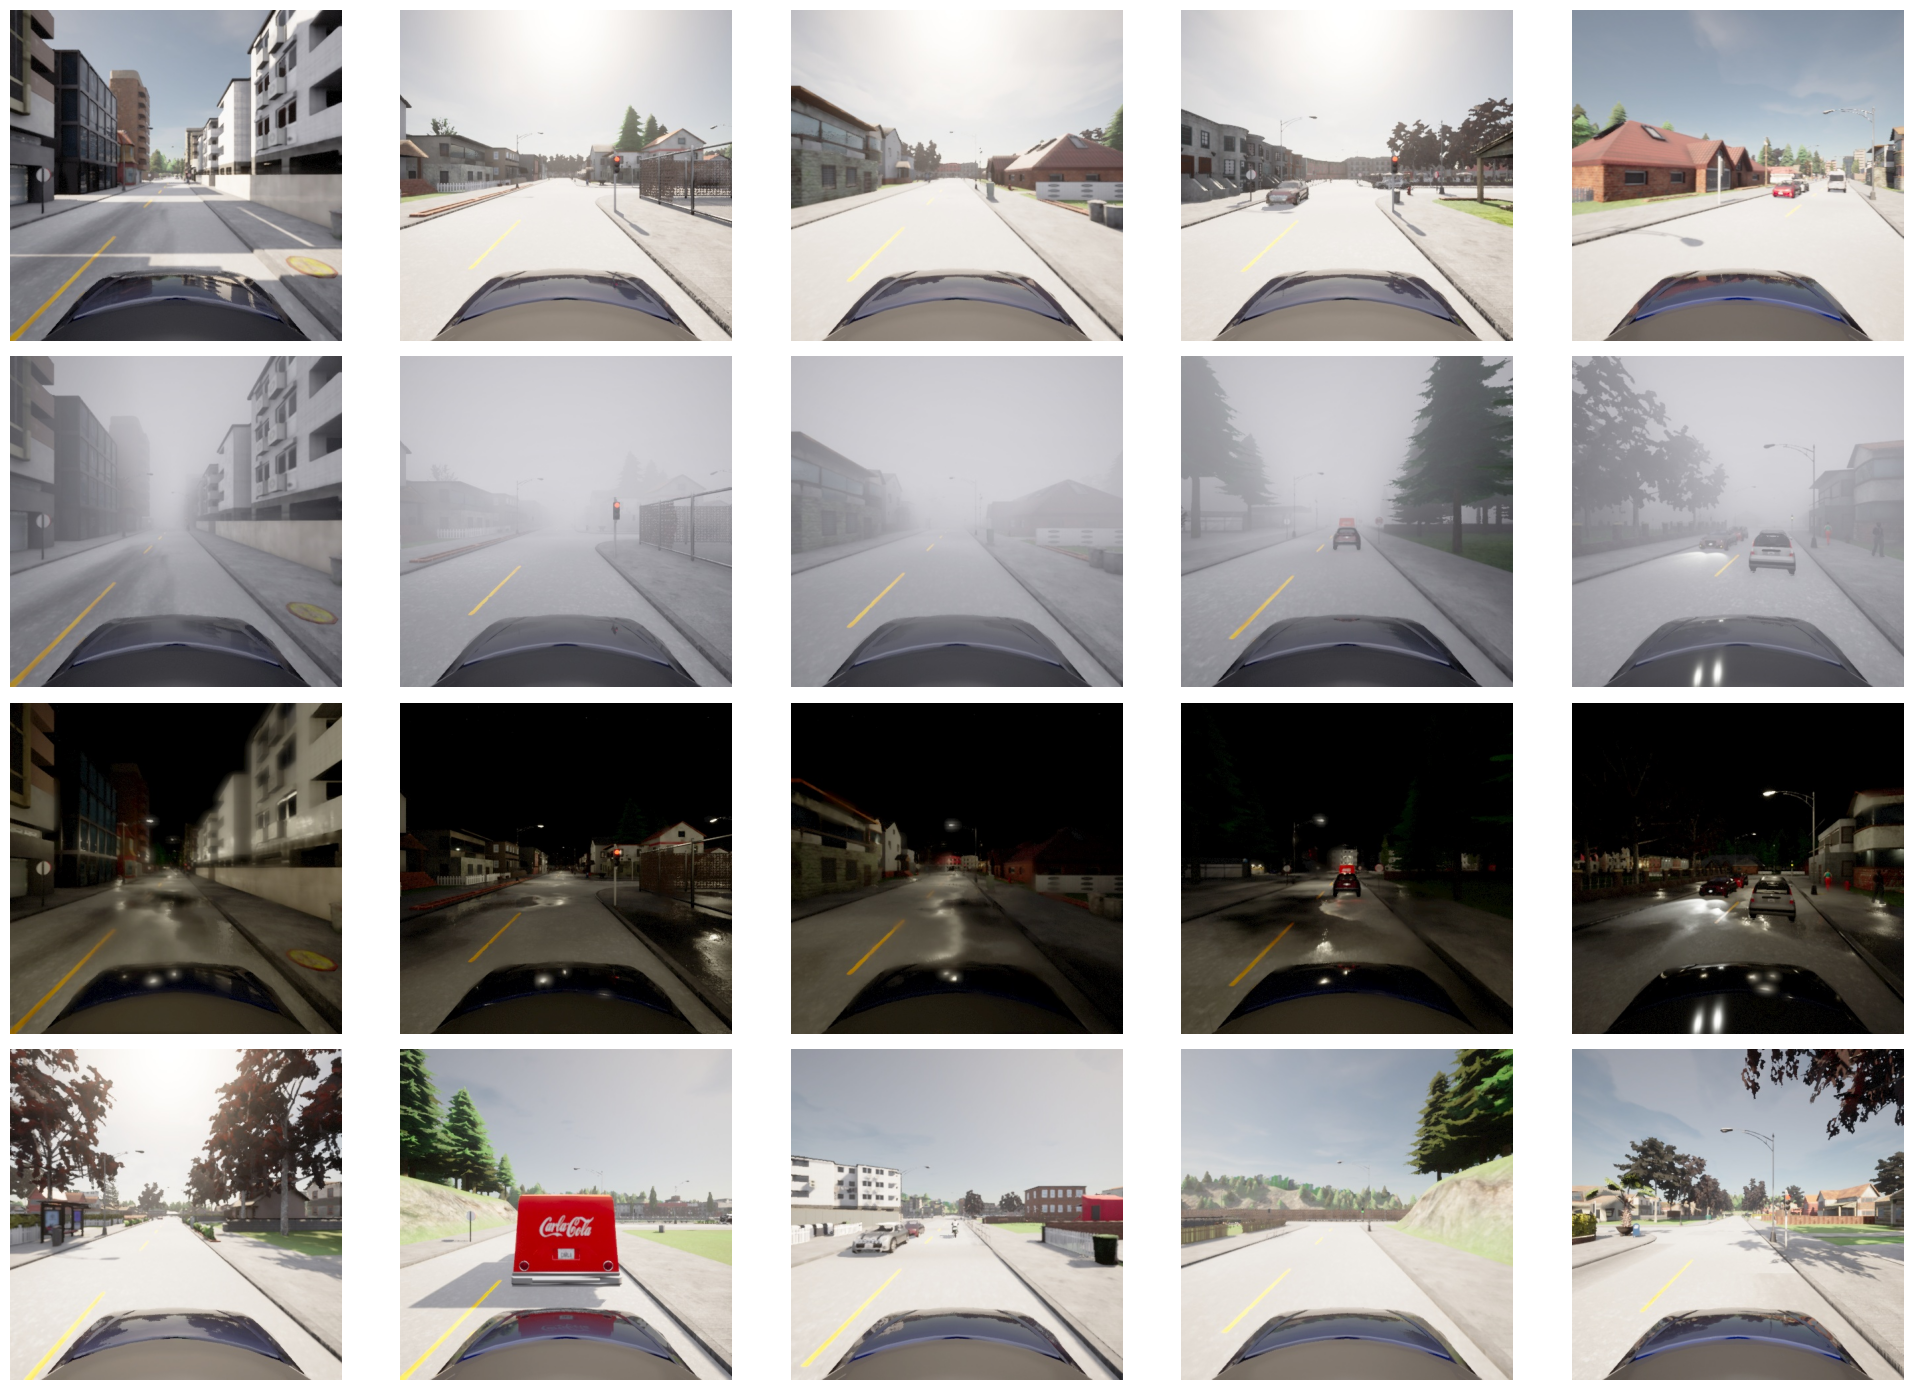

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

conditions = [
    ("Sunny", image_folder, files),
    ("Fog", fog_folder, fog_files),
    ("Night", night_folder, night_files),
    ("Town", town_folder, town_files)
]

selected = [0, 100, 500, 1000, 1500]

fig, axes = plt.subplots(4, 5, figsize=(20, 14))

for row, (condition, folder, filenames) in enumerate(conditions):

    for column, index in enumerate(selected):
        image = Image.open(
            folder / filenames[index]
        ).convert("RGB")

        axes[row, column].imshow(image)
        axes[row, column].axis("off")

        if column == 0:
            axes[row, column].set_ylabel(
                condition,
                fontsize=14
            )

plt.tight_layout()
plt.show()